# AEX 荷指 RFSV 波动率预测与回测

基于 Oxford-Man AEX rv5 数据，五年窗口进行 RFSV/AR/HAR 预测与 P-ratio 评估，用于与中国市场对比。

## 1. 导入与数据加载

In [1]:
import sys
sys.path.append('../models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HurstEstimator import HurstEstimator
from RFSVPredictor import (
    RFSVPredictor,
    predict_ar,
    predict_har,
    compute_p_ratio,
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['Arial Unicode MS']

In [45]:
# 加载 Oxford-Man AEX 数据，五年窗口
df_raw = pd.read_csv('../data/oxfordmanrealizedvolatilityindices.csv')
df_aex = df_raw[df_raw['Symbol'] == '.AEX'].copy()
date_col = df_aex.columns[0]
df_aex['date'] = pd.to_datetime(df_aex[date_col], utc=True).dt.tz_localize(None)
df_aex = df_aex.set_index('date').sort_index()
df_aex = df_aex[df_aex['rv5'] > 1e-12]
df = df_aex.loc['2014-08-01':'2018-06-27'].copy()

log_var = np.log(df['rv5'])
var_series = df['rv5']

print(f"数据范围: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"交易日数: {len(df)}")

数据范围: 2014-08-03 ~ 2018-06-26
交易日数: 997


## 2. 参数估计：H 与 ν²

In [46]:
hurst = HurstEstimator()
log_vol_series = 0.5 * np.log(df['rv5'])

START_IDX = 500
H, h_info = hurst.estimate_hurst_variogram(log_vol_series[:START_IDX], q=2.0)
nu_sq = np.exp(h_info['intercept'])

print(f"Hurst 指数 H = {H:.4f} (R² = {h_info['r_squared']:.4f})")
print(f"ν² = {nu_sq}")

Hurst 指数 H = 0.0920 (R² = 0.7968)
ν² = 0.13949057795731806


## 3. RFSV 滚动预测

In [47]:
deltas = [1, 5, 20]
rfsv_preds = {}

for delta in deltas:
    predictor = RFSVPredictor(H=H, nu_sq=nu_sq, delta=delta, window_ratio=2)
    preds = predictor.predict_rolling(log_var.values, start_idx=START_IDX)
    rfsv_preds[delta] = preds
    print(f"Δ={delta}: {len(preds)} 个预测值")

Δ=1: 496 个预测值
Δ=5: 492 个预测值
Δ=20: 477 个预测值


## 4. AR 与 HAR 基准

In [48]:
ar5_preds = {}
ar10_preds = {}
har_preds = {}

for delta in deltas:
    ar5_preds[delta] = predict_ar(log_var.values, delta=delta, p=5, train_window=START_IDX)
    ar10_preds[delta] = predict_ar(log_var.values, delta=delta, p=10, train_window=START_IDX)
    har_preds[delta] = predict_har(log_var.values, delta=delta, train_window=START_IDX)

## 5. 评估指标 P（MSE 比例）

In [49]:
mean_log_var = np.nanmean(log_var.values)
n = len(log_var)

results = []
for delta in deltas:
    actual = log_var.values[START_IDX + delta : n]
    p_rfsv = compute_p_ratio(actual, rfsv_preds[delta], mean_log_var)
    p_ar5 = compute_p_ratio(actual, ar5_preds[delta], mean_log_var)
    p_ar10 = compute_p_ratio(actual, ar10_preds[delta], mean_log_var)
    p_har = compute_p_ratio(actual, har_preds[delta], mean_log_var)
    results.append({
        'Δ': delta,
        'AR(5)': p_ar5,
        'AR(10)': p_ar10,
        'HAR(3)': p_har,
        'RFSV': p_rfsv,
    })

df_results = pd.DataFrame(results).set_index('Δ')
print("Table 5.1 风格 - log-variance 预测 P 值（AEX 荷指）")
print(df_results.round(3).to_string())

Table 5.1 风格 - log-variance 预测 P 值（AEX 荷指）
    AR(5)  AR(10)  HAR(3)   RFSV
Δ                               
1   0.348   0.356   0.338  0.424
5   0.524   0.515   0.502  0.527
20  0.790   0.798   0.786  0.714


## 6. P 值对比可视化

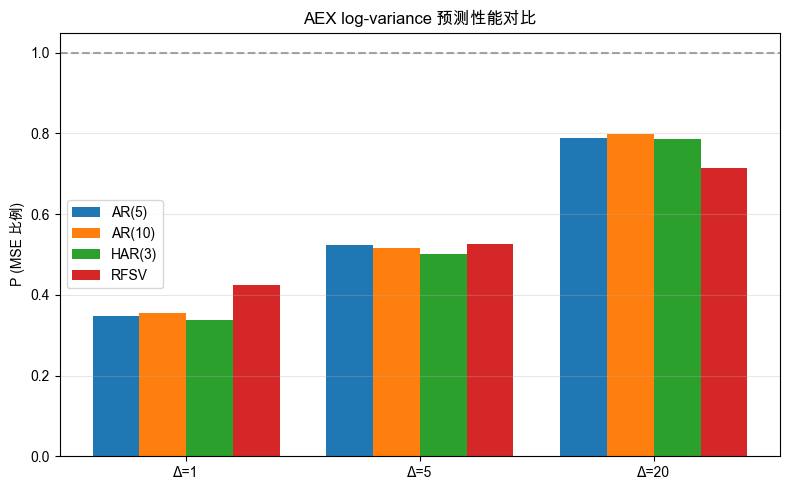

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(deltas))
width = 0.2

ax.bar(x - 1.5*width, df_results['AR(5)'], width, label='AR(5)')
ax.bar(x - 0.5*width, df_results['AR(10)'], width, label='AR(10)')
ax.bar(x + 0.5*width, df_results['HAR(3)'], width, label='HAR(3)')
ax.bar(x + 1.5*width, df_results['RFSV'], width, label='RFSV')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'Δ={d}' for d in deltas])
ax.set_ylabel('P (MSE 比例)')
ax.set_title('AEX log-variance 预测性能对比')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 回测：actual vs predicted 时序图（Δ=1）

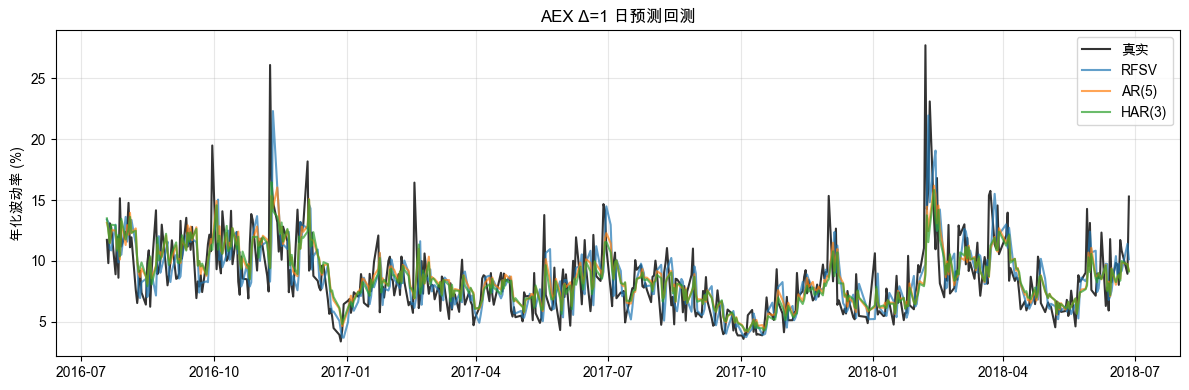

In [51]:
delta = 1
dates = df.index[START_IDX + delta : START_IDX + delta + len(rfsv_preds[delta])]
actual_vol = np.sqrt(np.exp(log_var.values[START_IDX + delta : START_IDX + delta + len(rfsv_preds[delta])]) * 252) * 100
rfsv_vol = np.sqrt(np.exp(rfsv_preds[delta]) * 252) * 100
ar5_vol = np.sqrt(np.exp(ar5_preds[delta]) * 252) * 100
har_vol = np.sqrt(np.exp(har_preds[delta]) * 252) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, actual_vol, 'k-', alpha=0.8, linewidth=1.5, label='真实')
ax.plot(dates, rfsv_vol, alpha=0.7, label='RFSV')
ax.plot(dates, ar5_vol, alpha=0.7, label='AR(5)')
ax.plot(dates, har_vol, alpha=0.7, label='HAR(3)')
ax.set_ylabel('年化波动率 (%)')
ax.set_title('AEX Δ=1 日预测回测')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

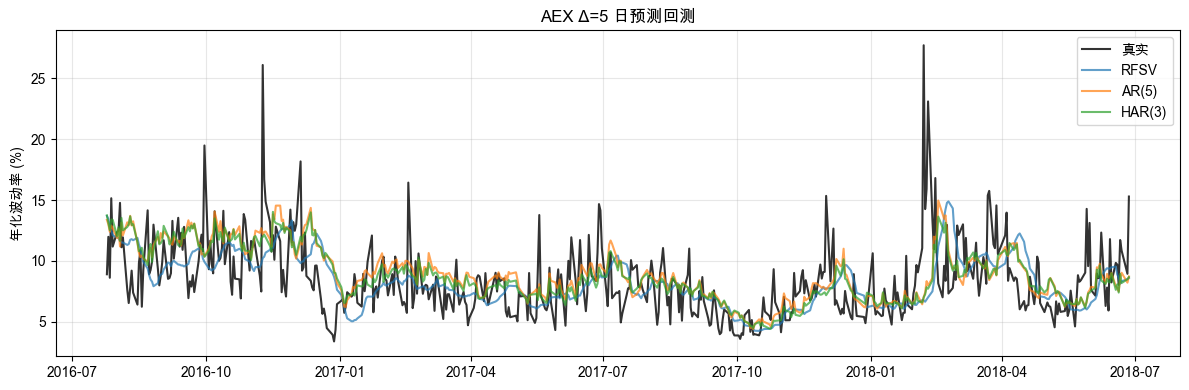

In [52]:
delta = 5
dates = df.index[START_IDX + delta : START_IDX + delta + len(rfsv_preds[delta])]
actual_vol = np.sqrt(np.exp(log_var.values[START_IDX + delta : START_IDX + delta + len(rfsv_preds[delta])]) * 252) * 100
rfsv_vol = np.sqrt(np.exp(rfsv_preds[delta]) * 252) * 100
ar5_vol = np.sqrt(np.exp(ar5_preds[delta]) * 252) * 100
har_vol = np.sqrt(np.exp(har_preds[delta]) * 252) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, actual_vol, 'k-', alpha=0.8, linewidth=1.5, label='真实')
ax.plot(dates, rfsv_vol, alpha=0.7, label='RFSV')
ax.plot(dates, ar5_vol, alpha=0.7, label='AR(5)')
ax.plot(dates, har_vol, alpha=0.7, label='HAR(3)')
ax.set_ylabel('年化波动率 (%)')
ax.set_title('AEX Δ=5 日预测回测')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

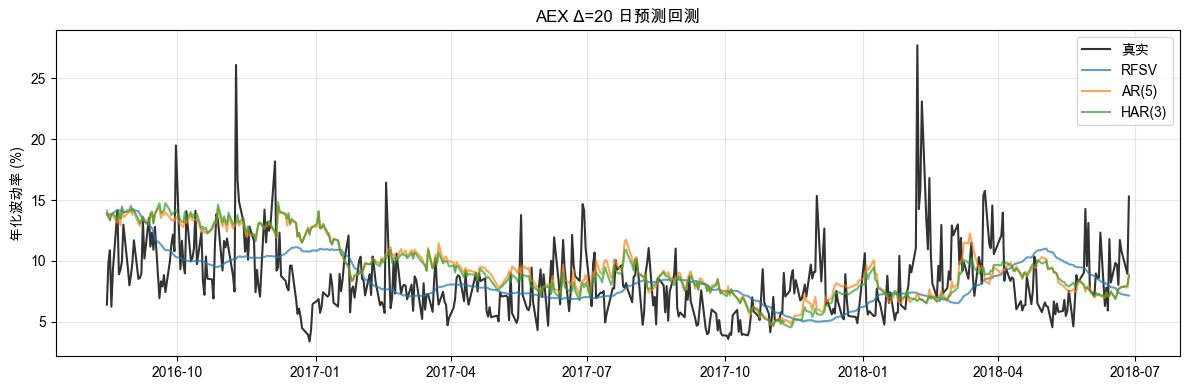

In [53]:
delta = 20
dates = df.index[START_IDX + delta : START_IDX + delta + len(rfsv_preds[delta])]
actual_vol = np.sqrt(np.exp(log_var.values[START_IDX + delta : START_IDX + delta + len(rfsv_preds[delta])]) * 252) * 100
rfsv_vol = np.sqrt(np.exp(rfsv_preds[delta]) * 252) * 100
ar5_vol = np.sqrt(np.exp(ar5_preds[delta]) * 252) * 100
har_vol = np.sqrt(np.exp(har_preds[delta]) * 252) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, actual_vol, 'k-', alpha=0.8, linewidth=1.5, label='真实')
ax.plot(dates, rfsv_vol, alpha=0.7, label='RFSV')
ax.plot(dates, ar5_vol, alpha=0.7, label='AR(5)')
ax.plot(dates, har_vol, alpha=0.7, label='HAR(3)')
ax.set_ylabel('年化波动率 (%)')
ax.set_title('AEX Δ=20 日预测回测')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()